In [ ]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [1]:
#GITHUB --> COLAB CLONE / env setup
import os
from google.colab import userdata

# 1. Get your access token
token = userdata.get('GH_TOKEN')

# 2. Clone the repo if it's not already there
repo_path = '/content/marl-tsc'
if not os.path.exists(repo_path):
    !git clone --branch zak_new --single-branch https://{token}@github.com/abergh18/marl-tsc.git

# 3. CRUCIAL: Move to the root directory
# This ensures that 'import models' or 'import utils' works correctly
%cd {repo_path}

# 4. Install dependencies
!pip install -r requirements.txt

/content/marl-tsc
  Using cached traci-1.26.0-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached sumolib-1.26.0-py2.py3-none-any.whl.metadata (2.6 kB)
Using cached traci-1.26.0-py2.py3-none-any.whl (138 kB)
Using cached sumolib-1.26.0-py2.py3-none-any.whl (233 kB)
  Attempting uninstall: sumolib
    Found existing installation: sumolib 1.27.0
    Uninstalling sumolib-1.27.0:
      Successfully uninstalled sumolib-1.27.0
  Attempting uninstall: traci
    Found existing installation: traci 1.27.0
    Uninstalling traci-1.27.0:
      Successfully uninstalled traci-1.27.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libsumo 1.27.0 requires traci>=1.27.0, but you have traci 1.26.0 which is incompatible.


In [2]:
!pip install eclipse-sumo libsumo

import os
os.environ["SUMO_HOME"] = "/usr/local/lib/python3.12/dist-packages/sumo"
os.environ["PATH"] += ":/usr/local/lib/python3.12/dist-packages/sumo/bin"

  Using cached traci-1.27.0-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached sumolib-1.27.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached traci-1.27.0-py2.py3-none-any.whl (138 kB)
Using cached sumolib-1.27.0-py2.py3-none-any.whl (236 kB)
  Attempting uninstall: sumolib
    Found existing installation: sumolib 1.26.0
    Uninstalling sumolib-1.26.0:
      Successfully uninstalled sumolib-1.26.0
  Attempting uninstall: traci
    Found existing installation: traci 1.26.0
    Uninstalling traci-1.26.0:
      Successfully uninstalled traci-1.26.0


In [3]:
from pathlib import Path
import sys
#Had to remove '.parent' for colab specific version
PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 4

def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))


In [5]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)


## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [7]:
# ==========================================
# MASTER VARIABLE: Controls the entire run
# ==========================================
EPISODE_STEPS = 400_000  # The number of actions/steps the RL agent takes per episode


# ==========================================
# Derived Parameters
# ==========================================
SECONDS_PER_ACTION = 5  # Matches the step logic in your SumoTrafficEnv
# The actual duration in SUMO seconds that the RL agent will experience
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION  # 3000 SUMO seconds

# To ensure continuous flow, spawn vehicles for 20% longer than the simulation runs.
# This guarantees that the network never empties out or hits ACT = 0.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)  # 3600 SUMO seconds

NUM_EPISODES = 30
EVALUATION_EPISODES = 10
TOTAL_TIMESTEPS = SIMULATION_DURATION
MIN_GREEN_SECONDS = 10


# ==========================================
# Generator Configuration
# ==========================================
generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,  # Extends past the simulation end!
    trip_period=2,                    # Steady stream: 1 car every 2 seconds
    seed=42,
)

paths = generator.generate_all()
print(f"Generated continuous flow configuration: {paths.config_file}")
print(f"Simulation Horizon: {SIMULATION_DURATION}s | Traffic Spawning Until: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)


Generated continuous flow configuration: /content/marl-tsc/outputs/config.sumocfg
Simulation Horizon: 2000000s | Traffic Spawning Until: 2400000s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [ ]:
# ==========================================
# 1. RANDOM BASELINE EVALUATION
# ==========================================
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO:Extract dynamically from the net file
    policy=random_actions,
    episodes=1,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps=600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

# ==========================================
# 2. FIXED-TIME BASELINE EVALUATION
# ==========================================
fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO: Extract dynamically from the net file
    policy=fixed_time_actions,
    episodes= 1,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps= 600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 1500 ACT 39 BUF 0)                
Finished Evaluation Episode 1/1 - Total Reward: -133.12
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (3ms ~= 333.33*RT, ~184000.00UPS, TraCI: 8ms, vehicles TOT 1160 ACT 552 BUF 
Finished Evaluation Episode 1/1 - Total Reward: -1335.24


In [ ]:
baseline_rows = [
    {
        "Policy": "Random",
        "Episodes": random_result["episodes"],
        "Mean total reward": random_result["mean_total_reward"],
        "Mean local queue": random_result["mean_local_queue"],
        "Total completed steps": random_result["total_completed_steps"],
        "Mean switches / episode": random_result["mean_switches_per_episode"],
    },
    {
        "Policy": "Fixed-Time",
        "Episodes": fixed_time_result["episodes"],
        "Mean total reward": fixed_time_result["mean_total_reward"],
        "Mean local queue": fixed_time_result["mean_local_queue"],
        "Total completed steps": fixed_time_result["total_completed_steps"],
        "Mean switches / episode": fixed_time_result["mean_switches_per_episode"],
    },
]
print_comparison_table(baseline_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 1        | -133.120          | 0.512            | 600                   | 1027.000               
Fixed-Time | 1        | -1335.235         | 5.514            | 600                   | 1196.000               


## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


### PPO

In [ ]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2856ms, vehicles TOT 0 ACT 0 BUF 0)                   
 Retrying in 1 seconds
Step #2400080.00 (0ms ?*RT. ?UPS, TraCI: 5ms, vehicles TOT 1200000 ACT 0 BUF 0)           tep #4500.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 2251 ACT 36 BUF 0)               ep #9000.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 4500 ACT 40 BUF 1)               p #13500.00 (0ms ?*RT. ?UPS, TraCI: 32ms, vehicles TOT 6751 ACT 33 BUF 0)               #18000.00 (1ms ~= 1000.00*RT, ~35000.00UPS, TraCI: 10ms, vehicles TOT 9001 ACT 35 BUF#22500.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 11250 ACT 32 BUF 1)             27000.00 (1ms ~= 1000.00*RT, ~42000.00UPS, TraCI: 10ms, vehicles TOT 13500 ACT 42 BU1500.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 15751 ACT 46 BUF 0)             000.00 (1ms ~= 1000.00*RT, ~37000.00UPS, TraCI: 14ms, vehic

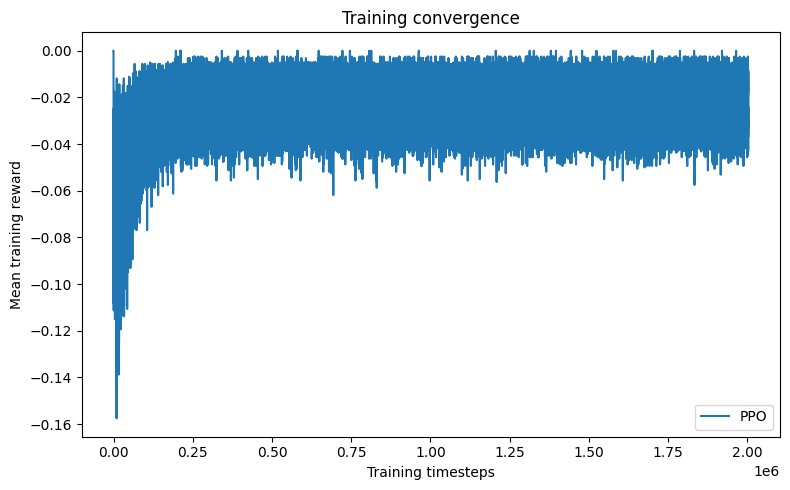

Saved PPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/ppo_sumo_traffic.zip


In [ ]:

fig, ax = plot_training_histories(ppo_history)
plt.show()

print("Saved PPO model:", ppo_model_path)

### MAPPO

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #2399000.00 (1ms ~= 1000.00*RT, ~31000.00UPS, TraCI: 6ms, vehicles TOT 111)          tep #4500.00 (1ms ~= 1000.00*RT, ~49000.00UPS, TraCI: 7ms, vehicles TOT 2251 ACT 49 BUF 0ep #9000.00 (1ms ~= 1000.00*RT, ~37000.00UPS, TraCI: 8ms, vehicles TOT 4500 ACT 37 BUF 1p #13500.00 (1ms ~= 1000.00*RT, ~39000.00UPS, TraCI: 8ms, vehicles TOT 6750 ACT 39 BUF  #18000.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 9001 ACT 37 BUF 0)               #22500.00 (1ms ~= 1000.00*RT, ~35000.00UPS, TraCI: 7ms, vehicles TOT 11250 ACT 35 BUF27000.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 13500 ACT 39 BUF 1)              1500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 15751 ACT 44 BUF 0)              000.00 (1ms ~= 1000.00*RT, ~38000.00UPS, TraCI: 7ms, vehicles TOT 18001 ACT 38 BUF00.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 20250 ACT 40 BUF 1)              0.00 (1ms

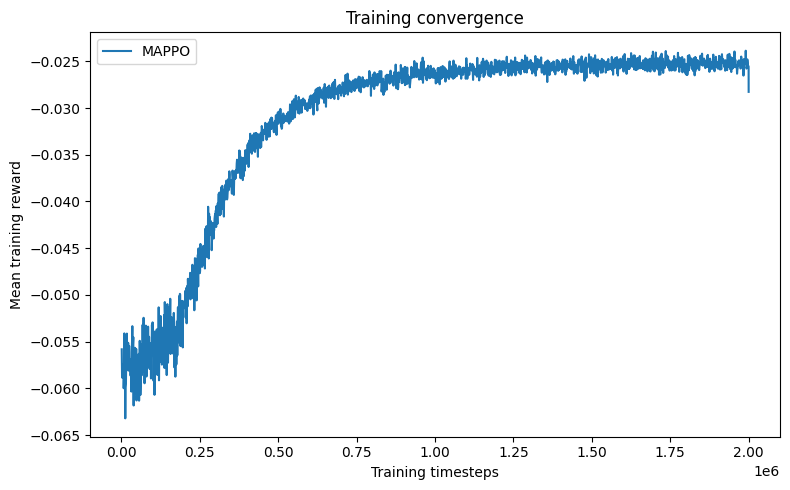

Saved MAPPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/models/mappo.pt


In [ ]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1024,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

print("Saved MAPPO model:", mappo_model_path)

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [ ]:
shared_mappo_result = evaluate_policy(
    config_file=paths.config_file,
    # 1. Pass None to dynamically extract the agents from the network file, matching training!
    traffic_light_ids=traffic_light_ids,
    policy=mappo_model,
    episodes=1, #EVALUATION_EPISODES,
    # 2. FIX: Must be EPISODE_STEPS, not SIMULATION_DURATION
    max_steps=EPISODE_STEPS,
    seed=42,
    # 3. Pass every environment hyperparameter to ensure observation spaces align perfectly
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": EPISODE_STEPS,
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #2000000.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 1000000 ACT 30 BUF 0)         tep #4500.00 (1ms ~= 1000.00*RT, ~26000.00UPS, TraCI: 6ms, vehicles TOT 2251 ACT 26 BUF 0ep #9000.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 4500 ACT 26 BUF 1)                p #13500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 6751 ACT 23 BUF 0)                #18000.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 9001 ACT 27 BUF 0)               #22500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 11250 ACT 24 BUF 1)              27000.00 (1ms ~= 1000.00*RT, ~28000.00UPS, TraCI: 7ms, vehicles TOT 13500 ACT 28 BUF1500.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 15751 ACT 28 BUF 0)             000.00 (1ms ~= 1000.00*RT, ~23000.00UPS, TraCI: 8ms, vehicles TOT 18001 ACT 23 BUF00.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 20250 ACT 25 BUF 1)             0.00 (0ms

In [ ]:
shared_ppo_result = evaluate_policy(
    config_file=paths.config_file,
    # 1. Pass None to dynamically extract the agents from the network file, matching training!
    traffic_light_ids=traffic_light_ids,
    policy=ppo_model,
    episodes=1, #EVALUATION_EPISODES,
    # 2. FIX: Must be EPISODE_STEPS, not SIMULATION_DURATION
    max_steps=EPISODE_STEPS,
    seed=42,
    # 3. Pass every environment hyperparameter to ensure observation spaces align perfectly
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": EPISODE_STEPS,
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #2000000.00 (1ms ~= 1000.00*RT, ~30000.00UPS, TraCI: 8ms, vehicles TOT 1000000 ACT 30tep #4500.00 (1ms ~= 1000.00*RT, ~24000.00UPS, TraCI: 18ms, vehicles TOT 2251 ACT 24 BUF ep #9000.00 (1ms ~= 1000.00*RT, ~30000.00UPS, TraCI: 47ms, vehicles TOT 4500 ACT 30 BUF p #13500.00 (0ms ?*RT. ?UPS, TraCI: 14ms, vehicles TOT 6751 ACT 26 BUF 0)               #18000.00 (2ms ~= 500.00*RT, ~12500.00UPS, TraCI: 26ms, vehicles TOT 9001 ACT 25 BUF #22500.00 (0ms ?*RT. ?UPS, TraCI: 55ms, vehicles TOT 11251 ACT 23 BUF 0)             27000.00 (1ms ~= 1000.00*RT, ~29000.00UPS, TraCI: 46ms, vehicles TOT 13500 ACT 29 BU1500.00 (0ms ?*RT. ?UPS, TraCI: 52ms, vehicles TOT 15751 ACT 31 BUF 0)             000.00 (1ms ~= 1000.00*RT, ~22000.00UPS, TraCI: 19ms, vehicles TOT 18001 ACT 22 BU00.00 (0ms ?*RT. ?UPS, TraCI: 20ms, vehicles TOT 20251 ACT 27 BUF 0)             0.00 (0ms

In [ ]:
comparison_rows = baseline_rows + [
    {
        "Policy": "Shared PPO",
        "Episodes": shared_ppo_result["episodes"],
        "Mean total reward": shared_ppo_result["mean_total_reward"],
        "Mean local queue": shared_ppo_result["mean_local_queue"],
        "Total completed steps": shared_ppo_result["total_completed_steps"],
        "Mean switches / episode": shared_ppo_result["mean_switches_per_episode"],
    },
#comparison_rows = baseline_rows + [
        {
        "Policy": "MAPPO",
        "Episodes": shared_mappo_result["episodes"],
        "Mean total reward": shared_mappo_result["mean_total_reward"],
        "Mean local queue": shared_mappo_result["mean_local_queue"],
        "Total completed steps": shared_mappo_result["total_completed_steps"],
        "Mean switches / episode": shared_mappo_result["mean_switches_per_episode"],
    },
]

print_comparison_table(comparison_rows)


Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 1        | -133.120          | 0.512            | 600                   | 1027.000               
Fixed-Time | 1        | -1335.235         | 5.514            | 600                   | 1196.000               
Shared PPO | 1        | -34574.735        | 0.168            | 400000                | 775731.000             
MAPPO      | 1        | -34804.715        | 0.172            | 400000                | 727299.000             


### Traci Escape Hatch

In [89]:
on = True
if on:
    # Stop Traci processes if not already stopped, to prevent connection issues in subsequent runs
    import sys

    # 1. Force clear TraCI's internal connection registries
    try:
        import traci
        traci.switch("default")
        traci.close()
    except Exception:
        pass

    try:
        # Completely purge the connection dictionary tracking connections
        import traci.main
        traci.main._connections.clear()
        print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # 2. Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        print("Flushed TraCI module from Python runtime memory.")

    # 3. Re-import fresh
    import traci
    print("TraCI state successfully reset!")

Flushed TraCI module from Python runtime memory.
TraCI state successfully reset!


# Graph Stuff


In [10]:
generator_graphs = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=2_000,#TRAFFIC_SPAWN_DURATION,  # TEMPORARY TEST
    trip_period=2,                    # Steady stream: 1 car every 2 seconds
    seed=42,
)

In [8]:
#paths = generator_graphs.generate_all()
paths = generator.generate_all()

### Environment and Smoke Tests

In [8]:
from marl_tsc.graph_based.graph_builder import GraphBuilder

builder = GraphBuilder(paths.network_file)

topology = builder.build()
print("Topology output:")
print("List of Nodes")
print(topology.agent_ids)
print("Edge Index:Columns Represent source --> Target")
print(topology.edge_index)

Topology output:
List of Nodes
['B1', 'B2', 'C1', 'C2']
Edge Index:Columns Represent source --> Target
tensor([[0, 3, 2, 2, 0, 1, 3, 1],
        [1, 1, 0, 3, 2, 0, 2, 3]])


In [9]:
tls = next(iter(builder.net.getTrafficLights()))

connections = tls.getConnections()

print(connections[0])

incoming_lane = connections[0][0]
outgoing_lane = connections[0][1]

print(type(incoming_lane))
print(type(outgoing_lane))

print(sorted(
    attr
    for attr in dir(incoming_lane)
    if not attr.startswith("_")
)[:50])

[<sumolib.net.lane.Lane object at 0x7df84ce781a0>, <sumolib.net.lane.Lane object at 0x7df84ce79580>, 15]
<class 'sumolib.net.lane.Lane'>
<class 'sumolib.net.lane.Lane'>
['addOutgoing', 'allows', 'getBoundingBox', 'getClosestLanePosAndDist', 'getConnection', 'getEdge', 'getID', 'getIncoming', 'getIncomingConnections', 'getIndex', 'getLength', 'getNeigh', 'getOutgoing', 'getOutgoingEdges', 'getOutgoingLanes', 'getParam', 'getParams', 'getPermissions', 'getShape', 'getShape3D', 'getSpeed', 'getWidth', 'interpretOffset', 'isAccelerationLane', 'isNormal', 'setNeigh', 'setParam', 'setPermissions', 'setShape']


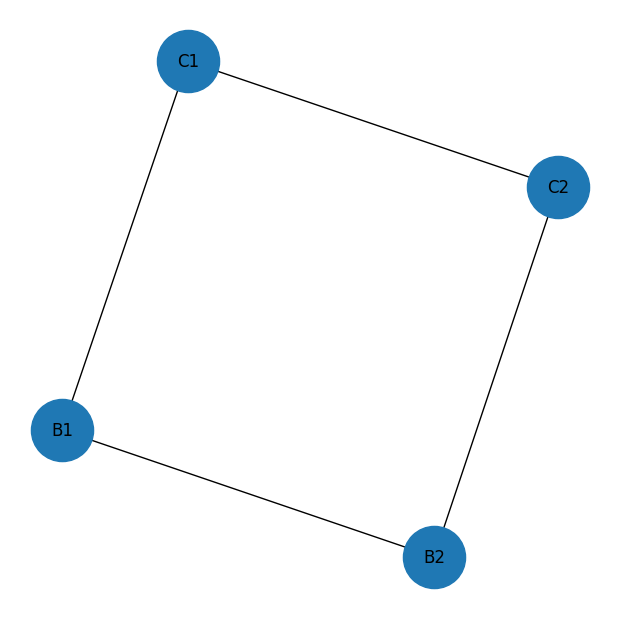

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for agent in topology.agent_ids:
    G.add_node(agent)

for src, dst in topology.edge_index.t().tolist():
    G.add_edge(
        topology.agent_ids[src],
        topology.agent_ids[dst]
    )

plt.figure(figsize=(6, 6))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
)

plt.show()

In [11]:
from marl_tsc.graph_based.graph_builder import GraphBuilder
from marl_tsc.graph_based.graph_env import GraphTrafficEnv

from marl_tsc.graph_based.encoders.gat_encoder import GATEncoder

from marl_tsc.graph_based.models.actor import ActorHead
from marl_tsc.graph_based.models.critic import CriticHead
from marl_tsc.graph_based.models.graph_policy import GraphPolicy


# ------------------------------------------------------------------
# 1. Build graph topology
# ------------------------------------------------------------------

topology = GraphBuilder(
    paths.network_file
).build()

print("Agents:", topology.agent_ids)
print("Edge Index Shape:", topology.edge_index.shape)

assert len(topology.agent_ids) > 0
assert topology.edge_index.shape[0] == 2


# ------------------------------------------------------------------
# 2. Create graph environment
# ------------------------------------------------------------------

env = GraphTrafficEnv(
    config_file=paths.config_file,
    network_file=paths.network_file,
    possible_agents=topology.agent_ids,
    max_steps=100,
    seed=42,
)

graph_obs, infos = env.reset(seed=42)

print("\nGraph:")
print(graph_obs)

assert graph_obs.graph.x.shape[0] == len(topology.agent_ids)
assert graph_obs.graph.edge_index.shape[0] == 2


# ------------------------------------------------------------------
# 3. Encoder
# ------------------------------------------------------------------

obs_dim = graph_obs.graph.x.shape[1]

encoder = GATEncoder(
    obs_dim=obs_dim,
    hidden_dim=64,
)

encoder_output = encoder(graph_obs)

print("\nEncoder:")
print("Node Embeddings:", encoder_output.node_embeddings.shape)
print("Graph Embedding:", encoder_output.graph_embedding.shape)

assert encoder_output.node_embeddings.shape == (
    len(topology.agent_ids),
    64,
)

assert encoder_output.graph_embedding.shape == (64,)


# ------------------------------------------------------------------
# 4. Heads
# ------------------------------------------------------------------

action_dim = env.action_spaces[
    topology.agent_ids[0]
].n

actor = ActorHead(
    embedding_dim=64,
    action_dim=action_dim,
)

critic = CriticHead(
    embedding_dim=64,
)

logits = actor(encoder_output)
value = critic(encoder_output)

print("\nHeads:")
print("Logits:", logits.shape)
print("Value:", value.shape)

assert logits.shape == (
    len(topology.agent_ids),
    action_dim,
)

assert value.shape == (1,)


# ------------------------------------------------------------------
# 5. Full policy
# ------------------------------------------------------------------

policy = GraphPolicy(
    encoder=encoder,
    actor_head=actor,
    critic_head=critic,
)

output = policy(graph_obs)

print("\nPolicy:")
print("Policy Logits:", output.logits.shape)
print("Policy Value:", output.value.shape)

assert output.logits.shape == (
    len(topology.agent_ids),
    action_dim,
)

assert output.value.shape == (1,)

print("\nGRAPH STACK SMOKE TEST PASSED")

env.close()

Agents: ['B1', 'B2', 'C1', 'C2']
Edge Index Shape: torch.Size([2, 8])
 Retrying in 1 seconds
 Retrying in 1 seconds

Graph:
GraphObservation(graph=Data(x=[4, 10], edge_index=[2, 8]), agent_ids=['B1', 'B2', 'C1', 'C2'], metadata={})

Encoder:
Node Embeddings: torch.Size([4, 64])
Graph Embedding: torch.Size([64])

Heads:
Logits: torch.Size([4, 4])
Value: torch.Size([1])

Policy:
Policy Logits: torch.Size([4, 4])
Policy Value: torch.Size([1])

GRAPH STACK SMOKE TEST PASSED


In [12]:
import torch
import torch_geometric
from marl_tsc.graph_based.graph_runner import GraphRunner
from marl_tsc.graph_based.graph_rollout import GraphRollout
from marl_tsc.graph_based.advantage_estimator import (
    AdvantageEstimator,
)

# --------------------------------------------------
# 1. Collect rollout
# --------------------------------------------------

runner = GraphRunner(
    env=env,
    policy=policy,
)

rollout = runner.collect_rollout(
    num_steps=10,
    seed=42,
)

print("Transitions:", len(rollout))

assert len(rollout) > 0

# --------------------------------------------------
# 2. Transition checks
# --------------------------------------------------

first = rollout[0]

print("\nTransition:")
print(type(first))

print("Actions:", first.action_dict)
print("Log Prob Shape:", first.log_prob.shape)
print("Logits Shape:", first.logits.shape)
print("Value Shape:", first.value.shape)

assert first.log_prob.shape == (
    len(topology.agent_ids),
)

assert first.logits.shape[0] == len(
    topology.agent_ids
)

assert first.value.shape == (1,)

# --------------------------------------------------
# 3. Rollout batch
# --------------------------------------------------

batch = GraphRollout.from_transitions(
    rollout,
    topology.agent_ids,
)

print("\nRollout Batch:")
print("Actions:", batch.actions.shape)
print("Log Probs:", batch.log_probs.shape)
print("Logits:", batch.logits.shape)
print("Values:", batch.values.shape)
print("Rewards:", batch.rewards.shape)
print("Dones:", batch.dones.shape)

assert batch.actions.shape == (
    len(rollout),
    len(topology.agent_ids),
)

assert batch.log_probs.shape == (
    len(rollout),
    len(topology.agent_ids),
)

assert batch.rewards.shape == (
    len(rollout),
    len(topology.agent_ids),
)

assert batch.values.shape == (
    len(rollout),
)

assert batch.dones.shape == (
    len(rollout),
)

# --------------------------------------------------
# 4. Advantage estimation
# --------------------------------------------------

adv_batch = (
    AdvantageEstimator
    .compute_gae(batch)
)

print("\nAdvantages:")
print(
    "Advantages:",
    adv_batch.advantages.shape,
)

print(
    "Returns:",
    adv_batch.returns.shape,
)

assert (
    adv_batch.advantages.shape
    ==
    batch.values.shape
)

assert (
    adv_batch.returns.shape
    ==
    batch.values.shape
)

assert not torch.isnan(
    adv_batch.advantages
).any()

assert not torch.isnan(
    adv_batch.returns
).any()

# --------------------------------------------------
# 5. Sample outputs
# --------------------------------------------------

print("\nSample Values")

print(
    "Advantages:",
    adv_batch.advantages[:5]
)

print(
    "Returns:",
    adv_batch.returns[:5]
)

print(
    "\n✅ PHASE 2 GRAPH ROLLOUT PIPELINE PASSED"
)

 Retrying in 1 seconds
Transitions: 10

Transition:
<class 'marl_tsc.graph_based.graph_runner.Transition'>
Actions: {'B1': 0, 'B2': 1, 'C1': 2, 'C2': 3}
Log Prob Shape: torch.Size([4])
Logits Shape: torch.Size([4, 4])
Value Shape: torch.Size([1])

Rollout Batch:
Actions: torch.Size([10, 4])
Log Probs: torch.Size([10, 4])
Logits: torch.Size([10, 4, 4])
Values: torch.Size([10])
Rewards: torch.Size([10, 4])
Dones: torch.Size([10])

Advantages:
Advantages: torch.Size([10])
Returns: torch.Size([10])

Sample Values
Advantages: tensor([-0.1953, -0.2048, -0.2152, -0.2176, -0.2252])
Returns: tensor([-0.0404, -0.0510, -0.0623, -0.0687, -0.0782])

✅ PHASE 2 GRAPH ROLLOUT PIPELINE PASSED


In [13]:
def evaluate_policy(env, policy, steps=100):

    graph_obs, infos = env.reset()

    total_reward = 0

    for _ in range(steps):

        output = policy(graph_obs)

        actions = output.logits.argmax(
            dim=1
        )

        action_dict = {
            agent_id: int(action)
            for agent_id, action in zip(
                graph_obs.agent_ids,
                actions,
            )
        }

        (
            graph_obs,
            rewards,
            terms,
            truncs,
            infos,
        ) = env.step(action_dict)

        total_reward += sum(
            rewards.values()
        )

    return total_reward

In [14]:
num_params = sum(
    p.numel()
    for p in policy.parameters()
)

print(
    f"Trainable parameters: {num_params:,}"
)

Trainable parameters: 28,549


In [15]:
import copy

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=2e-4,
)

from marl_tsc.graph_based.graph_ctde_trainer import (
    GraphCTDETrainer,
)

trainer = GraphCTDETrainer(
    env=env,
    policy=policy,
    optimizer=optimizer,
    rollout_steps=10,
)

before = copy.deepcopy(
    next(
        policy.parameters()
    ).detach()
)

stats = trainer.train_step()

after = next(
    policy.parameters()
).detach()

print(stats)

print(
    torch.equal(
        before,
        after,
    )
)

 Retrying in 1 seconds
{'actor_loss': 0.006886100862175226, 'critic_loss': 0.04926927387714386, 'total_loss': 0.05615537613630295, 'rollout_length': 10}
False


In [16]:
import importlib

import marl_tsc.graph_based.graph_runner

importlib.reload(
    #marl_tsc.graph_based.graph_runner,
    marl_tsc.graph_based.graph_rollout
)

from marl_tsc.graph_based.graph_runner import GraphRunner
import marl_tsc.graph_based.graph_rollout

In [28]:
import torch

# ----------------------------------
# Evaluation helper
# ----------------------------------

def evaluate_policy(env, policy, steps=100):

    graph_obs, _ = env.reset()

    total_reward = 0.0

    for _ in range(steps):

        with torch.no_grad():

            output = policy(graph_obs)

            actions = output.logits.argmax(dim=1)

        action_dict = {
            agent_id: int(action)
            for agent_id, action in zip(
                graph_obs.agent_ids,
                actions,
            )
        }

        (
            graph_obs,
            rewards,
            terminations,
            truncations,
            infos,
        ) = env.step(action_dict)

        total_reward += sum(
            rewards.values()
        )

        if any(truncations.values()):
            break

    return total_reward


# ----------------------------------
# Fresh optimizer
# ----------------------------------

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3,
)

# ----------------------------------
# Trainer
# ----------------------------------

trainer = GraphCTDETrainer(
    env=env,
    policy=policy,
    optimizer=optimizer,
    rollout_steps=64,
)

# ----------------------------------
# Baseline evaluation
# ----------------------------------

before_reward = evaluate_policy(
    env,
    policy,
)

print(f"Before Training: {before_reward:.4f}")

# ----------------------------------
# Train
# ----------------------------------

for iteration in range(100):

    stats = trainer.train_step()

    if (iteration + 1) % 10 == 0:

        print(
            f"Iter {iteration + 1:3d} | "
            f"Actor {stats['actor_loss']:.4f} | "
            f"Critic {stats['critic_loss']:.4f}"
        )

# ----------------------------------
# Final evaluation
# ----------------------------------

after_reward = evaluate_policy(
    env,
    policy,
)

print()
print(f"After Training:  {after_reward:.4f}")
print(f"Improvement:     {after_reward - before_reward:.4f}")

# ----------------------------------
# Inspect learned policy
# ----------------------------------

graph_obs, _ = env.reset()

with torch.no_grad():

    output = policy(graph_obs)

print()
print("Greedy Actions:")
print(output.logits.argmax(dim=1))

print()
print("Logits:")
print(output.logits)

 Retrying in 1 seconds
Before Training: -18.3250
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  10 | Actor -0.0230 | Critic 0.2982
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  20 | Actor -0.0206 | Critic 0.3509
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  30 | Actor 0.0175 | Critic 0.2545
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 

In [29]:
def eval_constant(env, action, steps=100):

    graph_obs, _ = env.reset()

    total_reward = 0

    for _ in range(steps):

        action_dict = {
            agent: action
            for agent in env.agent_ids
        }

        graph_obs, rewards, *_ = env.step(
            action_dict
        )

        total_reward += sum(
            rewards.values()
        )

    return total_reward


print(eval_constant(env, 0))
print(eval_constant(env, 1))
print(eval_constant(env, 2))
print(eval_constant(env, 3))

 Retrying in 1 seconds
-18.325000000000006
 Retrying in 1 seconds
-18.8025
 Retrying in 1 seconds
-18.6275
 Retrying in 1 seconds
-17.189999999999994


In [30]:
from marl_tsc.graph_based.base_trainer import BaseGraphTrainer


class DummyTrainer(BaseGraphTrainer):

    def update(
        self,
        rollout_batch,
        advantage_batch,
    ):

        print(type(rollout_batch))
        print(type(advantage_batch))

        print()

        print("Actions:")
        print(rollout_batch.actions.shape)

        print()

        print("Advantages:")
        print(advantage_batch.advantages.shape)

        print()

        print("Returns:")
        print(advantage_batch.returns.shape)

        return {
            "dummy_loss": 0.0,
        }


trainer = DummyTrainer(
    env=env,
    policy=policy,
    optimizer=optimizer,
    rollout_steps=10,
)

stats = trainer.train_step()

print()
print(stats)

 Retrying in 1 seconds
<class 'marl_tsc.graph_based.graph_rollout.RolloutBatch'>
<class 'marl_tsc.graph_based.advantage_estimator.AdvantageBatch'>

Actions:
torch.Size([10, 4])

Advantages:
torch.Size([10])

Returns:
torch.Size([10])

{'dummy_loss': 0.0}


In [19]:
from marl_tsc.graph_based.train_graph_ctde import (
    train_graph_ctde,
)

model, history, model_path = (
    train_graph_ctde(
        config_file=paths.config_file,
        network_file=paths.network_file,
        traffic_light_ids=traffic_light_ids,
        output_dir=OUTPUT_DIR,
        total_timesteps=1000,
        rollout_steps=64,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
        },
    )
)

print(type(model))
print(len(history))
print(model_path)
print(history[-1])

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
UPDATE RETURN: {'actor_loss': -0.010024823248386383, 'critic_loss': 0.4205641746520996, 'total_loss': 0.4105393588542938, 'rollout_length': 64, 'mean_training_reward': -0.0439160093665123}
 Retrying in 1 seconds
UPDATE RETURN: {'actor_loss': 0.027931027114391327, 'critic_loss': 0.9544763565063477, 'total_loss': 0.9824073910713196, 'rollout_length': 64, 'mean_training_reward': -0.06492187082767487}
 Retrying in 1 seconds
UPDATE RETURN: {'actor_loss': 0.00032742321491241455, 'critic_loss': 0.6474920511245728, 'total_loss': 0.647819459438324, 'rollout_length': 64, 'mean_training_reward': -0.05458007752895355}
 Retrying in 1 seconds
UPDATE RETURN: {'actor_loss': -0.023877784609794617, 'critic_loss': 0.5465885400772095, 'total_loss': 0.5227107405662537, 'rollout_length': 64, 'mean_training_reward': -0.05039063096046448}
 Retrying in 1 seconds
UPDATE RETURN: {'actor_loss': -0.008886456489562988, 'critic_loss': 0.41697213053

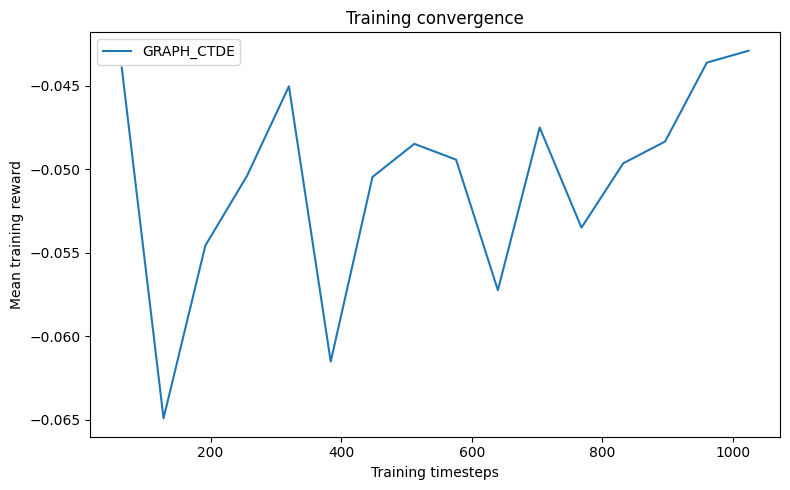

In [20]:
fig, ax = plot_training_histories(history)
plt.show()

#### Git stuff

In [11]:
!git status


On branch zak_new
Your branch is up to date with 'origin/zak_new'.

nothing to commit, working tree clean


In [144]:
!git add .

In [145]:
import shlex
commit_msg = '''
Bug within GraphCTDETrainer. Needs commiting before reloading notebook
'''
'''
TODO:
- Heterogenous networks
- Full Training run on bigger networks
- Possible integration with Andy's updated code
- Possible integration with Tom's networks
'''

"\nTODO: \n- Heterogenous networks\n- Full Training run on bigger networks\n- Possible integration with Andy's updated code\n- Possible integration with Tom's networks\n"

In [146]:
print(commit_msg)


Bug within GraphCTDETrainer. Needs commiting before reloading notebook



In [147]:
!git config --global user.email "zakfayle@gmail.com"
!git config --global user.name "IsaacFayle-Waters"
!git commit -m {shlex.quote(commit_msg)}

[zak_new 2782516] Bug within GraphCTDETrainer. Needs commiting before reloading notebook
 2 files changed, 18 insertions(+), 4 deletions(-)


In [148]:
!git push origin zak_new

Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (7/7), 744 bytes | 744.00 KiB/s, done.
Total 7 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/abergh18/marl-tsc.git
   5909ee1..2782516  zak_new -> zak_new
